In [1]:
import sys
sys.path.append('..')

In [2]:
from data_preparation import DataPreparation
from loader.dataset_factory import DatasetFactory
from model.gagnn import GAGNN
from model.loss import GAGNNLoss
from sklearn.metrics import f1_score
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from utils import Evaluator
import itertools
import json
import numpy as np
import os
import pandas as pd
import torch

In [3]:
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
set_seed(42)
torch.set_float32_matmul_precision('medium')


In [ ]:
# =============================================================================
# GNN Configuration
# =============================================================================
gnn_type = 'gat'
save_to_folder = 'saved_models_GAT'

# =============================================================================
# Model Architecture — Grid Search Lists
# =============================================================================
hidden_dims = [128]
out_dims = [128, 256]
num_layers_list = [2]
betas = [0.44]
mlp_hidden_dims = [128]
nn_t_hidden_dims = [128, 256]

heads_list = [5]

# =============================================================================
# Loss Weights
# =============================================================================
c1_list = [0.75]
c2_list = [0.75]
c3_list = [0.9]
laundry_weights = [2.0]

# =============================================================================
# Training & Cross-Validation
# =============================================================================
learning_rates = [0.0001]
max_norm_clipping = [5.0]

epochs_model_selection = 3000
epochs_train = 6000

minibatches = True
batch_size = 512
num_neighbors = [10, 10]

patience_selection = 200
moving_average_epochs = 5
patience_training = 300

print_every = 20
save_every = 100

# =============================================================================
# Class Imbalance
# =============================================================================
downsample = True

# =============================================================================
# Temporal Train / Validation / Test Split
# =============================================================================
date_time_1 = '2022-09-07 14:55:00'
date_time_2 = '2022-09-08 16:12:00'


import IBM AMLSim

In [5]:
from loader.dataset_factory import DatasetFactory

# Inizializza il loader specificando il nome canonico del dataset
loader = DatasetFactory.get_loader(
    "ibm_amlsim", 
    engine="pyarrow", 
    dtype_backend="pyarrow", 
    nrows=None
)
# pyarrow is faster and uses less memory, it takes NumPy place

# Carica i dati in memoria (file delle transazioni e, se presente, degli account)
loader.load()

# Stampa un riepilogo conciso del dataset caricato per verificare che sia tutto ok
loader.summary()

Loading IBM AMLSim transactions from: c:\Users\marti\OneDrive\Desktop\Tesi v2\Code\Multiclass\..\loader\..\data\ibm_amlsim\HI-Small_Trans.csv
  Loaded 5,078,345 rows.
Loading IBM AMLSim accounts from: c:\Users\marti\OneDrive\Desktop\Tesi v2\Code\Multiclass\..\loader\..\data\ibm_amlsim\HI-Small_accounts.csv
  Loaded 518,581 account records.
  Dataset : IBMAMLSimLoader
  Rows    : 5,078,345
  Columns : 11
  Fraud   : 5,177  (0.1019 %)



In [6]:
loader.print_features()


Column               Type         Description
--------------------------------------------------------------------------------
Timestamp            string[pyarrow] Date and time of the transaction
From Bank            int64[pyarrow] Numeric identifier of the originating bank  (e.g. [1, 10, 12, 3208, 3209])
Account              string[pyarrow] Hexadecimal ID of the sender account (node)
To Bank              int64[pyarrow] Numeric identifier of the receiving bank  (e.g. [1, 10, 12, 2439, 3209])
Account.1            string[pyarrow] Hexadecimal ID of the receiver account (node)
Amount Received      double[pyarrow] Transaction amount in the receiving currency
Receiving Currency   string[pyarrow] Currency received by the destination account  (e.g. ['US Dollar', 'Bitcoin', 'Euro', 'Australian Dollar', 'Yuan', 'Rupee'])
Amount Paid          double[pyarrow] Transaction amount in the paying currency
Payment Currency     string[pyarrow] Currency used by the sender  (e.g. ['US Dollar', 'Bitcoin',

Data preparation

In [7]:
from data_preparation import DataPreparation
import pandas as pd

# Otteniamo il dataframe raw delle transazioni dal nostro loader
transactions_df = loader.get_transactions()

# Parse multiclass patterns
data_prep = DataPreparation(scaler_type='robust')
transactions_df = data_prep.parse_patterns_file(transactions_df, '../data/ibm_amlsim/HI-Small_Patterns.txt')

# Calcoliamo la maschera di training per evitare data leakage nello scaler
ts_raw = pd.to_datetime(transactions_df['Timestamp'])
thresh_val = pd.to_datetime(date_time_1)
train_mask_raw = ts_raw < thresh_val

# Inizializziamo la classe scegliendo il robust scaler
data_prep = DataPreparation(scaler_type='robust')

# 1. Calcoliamo le feature standardizzate per le transazioni (gli archi E)
edges_features_df = data_prep.fit_transform_edges(transactions_df, train_mask=train_mask_raw)

# 2. Aggreghiamo le transazioni per ricavare l'embedding iniziale dei nodi (V)
nodes_features_df = data_prep.get_node_features(edges_features_df, train_mask=train_mask_raw)

print(f"Dimensione feature archi: {edges_features_df.shape}")
print(f"Dimensione feature nodi: {nodes_features_df.shape}")

# Stampa bilanciamento classi (Nodi e Archi)
print("\n--- Bilanciamento Dataset ---")
num_fraud_nodes = (nodes_features_df["Is Laundering"] > 0).sum()
num_legit_nodes = len(nodes_features_df) - num_fraud_nodes
print(f"Nodi fraudolenti: {num_fraud_nodes} ({num_fraud_nodes/len(nodes_features_df)*100:.2f}%)")
print(f"Nodi leciti:      {num_legit_nodes} ({num_legit_nodes/len(nodes_features_df)*100:.2f}%)")

num_fraud_edges = (edges_features_df["Is Laundering"] > 0).sum()
num_legit_edges = len(edges_features_df) - num_fraud_edges
print(f"Archi fraudolenti: {num_fraud_edges} ({num_fraud_edges/len(edges_features_df)*100:.2f}%)")
print(f"Archi leciti:      {num_legit_edges} ({num_legit_edges/len(edges_features_df)*100:.2f}%)")

print("\n--- Features degli archi ---")
print(list(edges_features_df.columns))

print("\n--- Features dei nodi ---")
print(list(nodes_features_df.columns))


Parsing patterns from ../data/ibm_amlsim/HI-Small_Patterns.txt...
Dropped 1968 illicit transactions lacking a specific multiclass pattern label.
Matched 3209 illicit transactions from patterns file.
Extracting time features (Unix time, Cyclic Hour, Day of Week, Week)...
Applying edge transformation (Amounts: robust, Time: standard)...
Aggregating node features and extracting ground truth labels...
Dimensione feature archi: (5076377, 54)
Dimensione feature nodi: (515039, 50)

--- Bilanciamento Dataset ---
Nodi fraudolenti: 3170 (0.62%)
Nodi leciti:      511869 (99.38%)
Archi fraudolenti: 3209 (0.06%)
Archi leciti:      5073168 (99.94%)

--- Features degli archi ---
['Amount Received', 'Amount Paid', 'Receiving Currency_Australian Dollar', 'Receiving Currency_Bitcoin', 'Receiving Currency_Brazil Real', 'Receiving Currency_Canadian Dollar', 'Receiving Currency_Euro', 'Receiving Currency_Mexican Peso', 'Receiving Currency_Ruble', 'Receiving Currency_Rupee', 'Receiving Currency_Saudi Riyal'

In [8]:
import torch
import numpy as np
import pandas as pd

print("--- Downsampling Strategy (1:1 Ratio) ---")
# 1. Identify Fraudulent and Legitimate Nodes
# A node is fraudulent if it was involved in at least one ML transaction
fraud_nodes = nodes_features_df[nodes_features_df["Is Laundering"] > 0].index
legit_nodes = nodes_features_df[nodes_features_df["Is Laundering"] == 0].index

print(f"Total Fraudulent Nodes: {len(fraud_nodes)}")
print(f"Total Legitimate Nodes (before sampling): {len(legit_nodes)}")

# 2. Sample Legitimate Nodes (1:1 ratio)
sampled_legit_nodes = pd.Series(legit_nodes).sample(n=len(fraud_nodes), random_state=42).values

# 3. Combine to form the final set of sampled users
sampled_users = set(fraud_nodes).union(set(sampled_legit_nodes))
print(f"Total Nodes after downsampling: {len(sampled_users)}")

# 4. Filter nodes_features_df and edges_features_df efficiently
nodes_features_df = nodes_features_df.loc[list(sampled_users)]

# Filter transactions: keep only those where BOTH sender and receiver are in sampled_users
edges_features_df = edges_features_df[
    edges_features_df['Account'].isin(sampled_users) & 
    edges_features_df['Account.1'].isin(sampled_users)
]

print(f"Total Edges after downsampling: {len(edges_features_df)}")

# 5. Map string Account IDs to integers (0 to N-1) for PyTorch Geometric
unique_nodes = nodes_features_df.index.unique()
node_mapping = pd.Series(index=unique_nodes, data=np.arange(len(unique_nodes)))

# 6. Extract edge_index
src = edges_features_df['Account'].map(node_mapping).values
dst = edges_features_df['Account.1'].map(node_mapping).values
edge_index = torch.tensor(np.vstack((src, dst)), dtype=torch.long)

# 7. Extract edge features and transaction labels
edge_features_cols = [c for c in edges_features_df.columns if c not in ['Account', 'Account.1', 'Is Laundering', 'Laundering_Type', 'Timestamp']]
edge_attr = torch.tensor(edges_features_df[edge_features_cols].values, dtype=torch.float)
y_trans = torch.tensor(edges_features_df['Laundering_Type'].values, dtype=torch.long).unsqueeze(1)

# 8. Extract node features and node labels
node_features_cols = [c for c in nodes_features_df.columns if c != 'Is Laundering']
x = torch.tensor(nodes_features_df[node_features_cols].values, dtype=torch.float)

y_node = torch.tensor(nodes_features_df['Is Laundering'].values, dtype=torch.float)

print(f"Node features shape: {x.shape}")
print(f"Edge index shape: {edge_index.shape}")
print(f"Edge features shape: {edge_attr.shape}")


--- Downsampling Strategy (1:1 Ratio) ---
Total Fraudulent Nodes: 3170
Total Legitimate Nodes (before sampling): 511869
Total Nodes after downsampling: 6340
Total Edges after downsampling: 17029
Node features shape: torch.Size([6340, 49])
Edge index shape: torch.Size([2, 17029])
Edge features shape: torch.Size([17029, 49])


In [9]:
import pandas as pd
from torch_geometric.data import Data

# Convert Timestamp column to datetime (use downsampled edges_features_df)
ts = pd.to_datetime(edges_features_df['Timestamp'])

# Thresholds for splits
thresh_val = pd.to_datetime(date_time_1)
thresh_test = pd.to_datetime(date_time_2)

# Create edge masks based on chronological splits
train_edge_mask = torch.tensor((ts < thresh_val).values, dtype=torch.bool)
val_edge_mask = torch.tensor(((ts >= thresh_val) & (ts < thresh_test)).values, dtype=torch.bool)
test_edge_mask = torch.tensor((ts >= thresh_test).values, dtype=torch.bool)

print(f"Train edges: {train_edge_mask.sum().item()} ({train_edge_mask.sum().item()/len(ts)*100:.1f}%)")
print(f"Val edges: {val_edge_mask.sum().item()} ({val_edge_mask.sum().item()/len(ts)*100:.1f}%)")
print(f"Test edges: {test_edge_mask.sum().item()} ({test_edge_mask.sum().item()/len(ts)*100:.1f}%)")

# Create node masks for NeighborLoader input_nodes
# A node is in the training set if it is connected to at least one training edge
train_nodes_idx = edge_index[:, train_edge_mask].flatten().unique()
train_node_mask = torch.zeros(x.shape[0], dtype=torch.bool)
train_node_mask[train_nodes_idx] = True

val_nodes_idx = edge_index[:, val_edge_mask].flatten().unique()
val_node_mask = torch.zeros(x.shape[0], dtype=torch.bool)
val_node_mask[val_nodes_idx] = True

test_nodes_idx = edge_index[:, test_edge_mask].flatten().unique()
test_node_mask = torch.zeros(x.shape[0], dtype=torch.bool)
test_node_mask[test_nodes_idx] = True

# Node mask: Using all True, as GAGNN expects a probability label for all nodes
node_mask = torch.ones(x.shape[0], dtype=torch.bool)

# Build PyG Data object
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y_trans=y_trans, y_node=y_node)
data.node_mask = node_mask
data.edge_train_mask = train_edge_mask
data.edge_val_mask = val_edge_mask
data.edge_test_mask = test_edge_mask
data.train_node_mask = train_node_mask
data.val_node_mask = val_node_mask
data.test_node_mask = test_node_mask


Train edges: 12607 (74.0%)
Val edges: 1161 (6.8%)
Test edges: 3261 (19.1%)


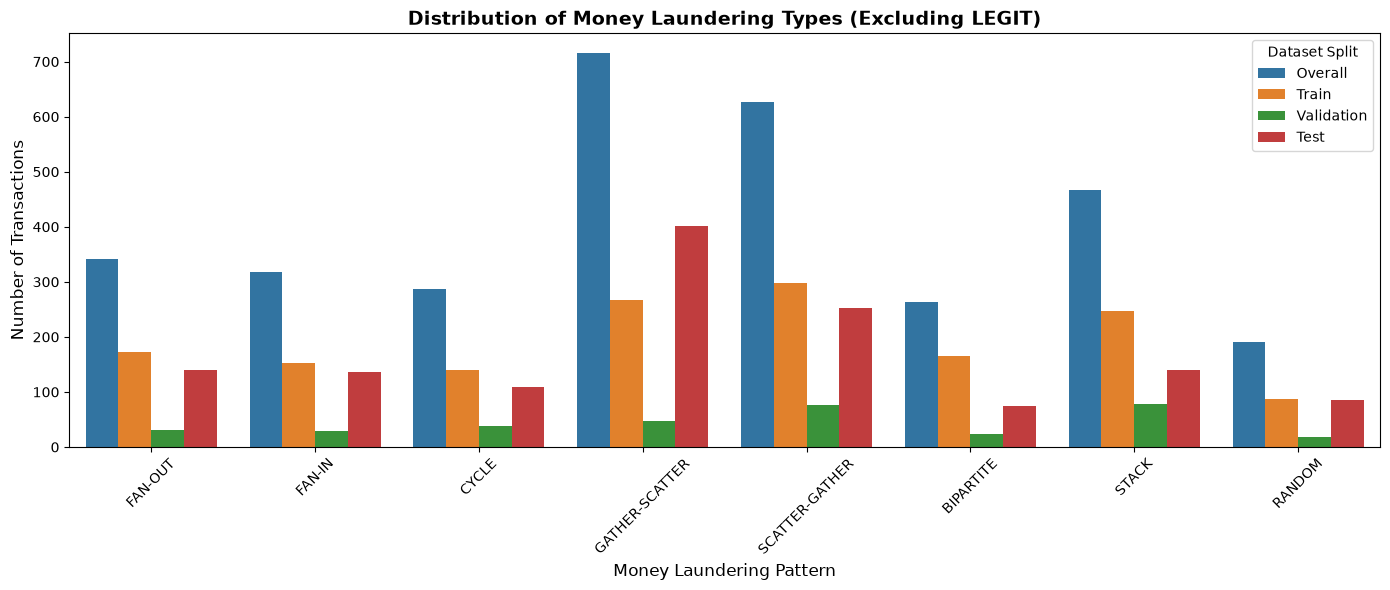

In [10]:
from utils import Evaluator

# Plot the distribution of money laundering types across the splits
Evaluator.plot_multiclass_distribution(
    y_trans=data.y_trans,
    train_edge_mask=data.edge_train_mask,
    val_edge_mask=data.edge_val_mask,
    test_edge_mask=data.edge_test_mask
)

### Model selection

In [11]:
import os
import json
import itertools
from model.gagnn import GAGNN
from model.loss import GAGNNLoss
from torch_geometric.loader import NeighborLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if minibatches:
    data = data.to(device)
    train_loader = NeighborLoader(
        data, num_neighbors=num_neighbors, batch_size=batch_size,
        input_nodes=data.train_node_mask, shuffle=True
    )
    
    val_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.val_node_mask, shuffle=False
    )
else:
    d_dev = data.to(device)
    train_loader = [d_dev]
    val_loader = [d_dev]

print(f"Batches per epoch (Train): {len(train_loader)} | (Val): {len(val_loader)}")

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("Computing class weights for the training set...")
y_train_flat = y_trans[train_edge_mask].view(-1).cpu().numpy()
classes = np.unique(y_train_flat)
class_weights_np = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_flat)

class_weights = torch.ones(9, dtype=torch.float)
for i, c in enumerate(classes):
    class_weights[int(c)] = class_weights_np[i]

class_weights = class_weights.to(device)
print(f"Class weights: {class_weights}")

keys = ['max_norm', 'hidden_dim', 'out_dim', 'heads', 'num_layers',
        'beta', 'mlp_hidden_dim', 'nn_t_hidden_dim', 'lr',
        'c1', 'c2', 'c3', 'laundry_weight']
combinations = list(itertools.product(
    max_norm_clipping, hidden_dims, out_dims, heads_list, num_layers_list,
    betas, mlp_hidden_dims, nn_t_hidden_dims, learning_rates,
    c1_list, c2_list, c3_list, laundry_weights
))

print(f"Total hyperparameter combinations: {len(combinations)}\n")
os.makedirs(save_to_folder, exist_ok=True)
with open(f"{save_to_folder}/configurations.txt", "w") as _f:
    _f.write(f"Total configurations tested: {len(combinations)}\n\n")
    _f.write("Hyperparameter grids:\n")
    _f.write(f"max_norm_clipping: {max_norm_clipping}\n")
    _f.write(f"hidden_dims: {hidden_dims}\n")
    _f.write(f"out_dims: {out_dims}\n")
    _f.write(f"heads_list: {heads_list}\n")
    _f.write(f"num_layers_list: {num_layers_list}\n")
    _f.write(f"betas: {betas}\n")
    _f.write(f"mlp_hidden_dims: {mlp_hidden_dims}\n")
    _f.write(f"nn_t_hidden_dims: {nn_t_hidden_dims}\n")
    _f.write(f"learning_rates: {learning_rates}\n")
    _f.write(f"c1_list: {c1_list}\n")
    _f.write(f"c2_list: {c2_list}\n")
    _f.write(f"c3_list: {c3_list}\n")
    _f.write(f"laundry_weights: {laundry_weights}\n")

from sklearn.metrics import f1_score
import numpy as np
best_val_f1 = -1.0
best_params = None

os.makedirs(save_to_folder, exist_ok=True)

for idx, combo in enumerate(combinations):
    params = dict(zip(keys, combo))
    print(f"--- Experiment {idx+1}/{len(combinations)} ---")
    print(params)
    
    model = GAGNN(
        node_in_dim=x.shape[1],
        edge_feat_dim=edge_attr.shape[1],
        hidden_dim=params['hidden_dim'],
        out_dim=params['out_dim'],
        heads=params['heads'],
        beta=params['beta'],
        mlp_hidden_dim=params['mlp_hidden_dim'],
        nn_t_hidden_dim=params['nn_t_hidden_dim'],
        minibatches=minibatches, num_classes=9,
        gnn_type=gnn_type,
        num_layers=params['num_layers']
    ).to(device)
    
    criterion = GAGNNLoss(c1=params['c1'], c2=params['c2'], c3=params['c3'], laundry_weight=class_weights, task='multiclass')
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    scaler = torch.amp.GradScaler('cuda')
    
    epochs_no_improve = 0
    best_model_val_f1 = -1.0
    
    for epoch in range(epochs_model_selection):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        evaluated_train = torch.zeros(data.num_edges, dtype=torch.bool, device=device)
        for batch in train_loader:
            if hasattr(batch, 'e_id'):
                e_id = batch.e_id
                new_mask = ~evaluated_train[e_id]
                evaluated_train[e_id] = True
            else:
                new_mask = torch.ones(batch.num_edges, dtype=torch.bool, device=device)
            train_mask = new_mask & batch.edge_train_mask
            if not train_mask.any():
                continue
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                p_node, p_trans, p_group, y_group = model(
                    batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                    y_node=batch.y_node, y_trans=batch.y_trans, trans_mask=train_mask
                )
            
            if p_group.numel() > 0:
                loss, _, _, _ = criterion(
                    p_node, batch.y_node.view(-1, 1),
                    p_trans, batch.y_trans,
                    p_group, y_group,
                    node_mask=batch.node_mask,
                    trans_mask=train_mask
                )
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=params['max_norm'])
                scaler.step(optimizer)
                scaler.update()
                epoch_loss += loss.item()
                n_batches += 1
                
        train_loss = epoch_loss / max(n_batches, 1)
        model.training_losses.append(train_loss)
        
        model.eval()
        all_preds = []
        all_labels = []
        evaluated_val = torch.zeros(data.num_edges, dtype=torch.bool, device=device)
        with torch.no_grad():
            for batch in val_loader:
                if hasattr(batch, 'e_id'):
                    e_id = batch.e_id
                    new_mask = ~evaluated_val[e_id]
                    evaluated_val[e_id] = True
                else:
                    new_mask = torch.ones(batch.num_edges, dtype=torch.bool, device=device)
                val_mask = new_mask & batch.edge_val_mask
                if not val_mask.any():
                    continue
                with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    p_node, p_trans, p_group, y_group = model(
                        batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                        y_trans=batch.y_trans, trans_mask=batch.edge_val_mask
                    )
                if p_group.numel() > 0:
                    p_trans_val = p_trans[val_mask]
                    y_trans_val = batch.y_trans[val_mask]
                    probs = torch.softmax(p_trans_val, dim=1)
                    probs_flat = probs
                    preds = torch.argmax(probs, dim=1)
                    labels = y_trans_val.view(-1).long()
                    all_preds.append(preds)
                    all_labels.append(labels)
                    
        if len(all_preds) > 0:
            all_preds = torch.cat(all_preds).cpu().numpy()
            all_labels = torch.cat(all_labels).cpu().numpy()
            val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        else:
            val_f1 = 0.0

        model.val_F1.append(val_f1)
        if val_f1 > best_model_val_f1:
            best_model_val_f1 = val_f1
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience_selection:
            print(f"Patience triggered at epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val F1-score: {val_f1:.4f}")
            break
            
        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val F1-score: {val_f1:.4f}")   
        
            
    print(f"Best Val F1-score for this config: {best_model_val_f1:.4f}")
    if best_model_val_f1 > best_val_f1:
        best_val_f1 = best_model_val_f1
        best_params = params
        model.save(f"{save_to_folder}/gagnn_best_model_selection.pt")
        print(">>> New Best Parameters! Model saved.")
    else:
        print(f"No improvement over best parameters. Current: {best_model_val_f1:.4f} | Best: {best_val_f1:.4f}")

print("\n=========================================")
print(f"Overall Best Val F1-score: {best_val_f1:.4f}")
print(f"Best Parameters: {best_params}")
print("=========================================")
with open(f"{save_to_folder}/best_params.json", "w") as f:
    json.dump(best_params, f, indent=4)

print("\nPlotting training history of the best model from model selection...")
best_selection_model = GAGNN.load_saved(f"{save_to_folder}/gagnn_best_model_selection.pt")
best_selection_model.plot_training_history()

Batches per epoch (Train): 11 | (Val): 2
Computing class weights for the training set...
Class weights: tensor([ 0.1264,  8.1441,  9.2156, 10.0056,  5.2464,  4.7006,  8.4384,  5.6712,
        16.1009], device='cuda:0')
Total hyperparameter combinations: 4

--- Experiment 1/4 ---
{'max_norm': 5.0, 'hidden_dim': 128, 'out_dim': 128, 'heads': 5, 'num_layers': 2, 'beta': 0.44, 'mlp_hidden_dim': 128, 'nn_t_hidden_dim': 128, 'lr': 0.0001, 'c1': 0.75, 'c2': 0.75, 'c3': 0.9, 'laundry_weight': 2.0}
Epoch 020 | Train Loss: 16.3576 | Val F1-score: 0.0552
Epoch 040 | Train Loss: 10.8552 | Val F1-score: 0.0852
Epoch 060 | Train Loss: 6.0998 | Val F1-score: 0.0860
Epoch 080 | Train Loss: 3.5794 | Val F1-score: 0.0464
Epoch 100 | Train Loss: 3.0942 | Val F1-score: 0.0622
Epoch 120 | Train Loss: 3.1009 | Val F1-score: 0.1055
Epoch 140 | Train Loss: 2.8641 | Val F1-score: 0.1100
Epoch 160 | Train Loss: 3.3546 | Val F1-score: 0.0788
Epoch 180 | Train Loss: 2.9111 | Val F1-score: 0.0177
Patience triggere

KeyboardInterrupt: 

### Training


Loading best hyperparameters for final training...

Starting final training on Train dataset with validation...
Batches per epoch (Final Train): 11
Train Epoch 020/6000 | Train Loss: 5.5020 | Val F1: 0.1242
Train Epoch 040/6000 | Train Loss: 3.1431 | Val F1: 0.1350
Train Epoch 060/6000 | Train Loss: 2.5413 | Val F1: 0.1741
Train Epoch 080/6000 | Train Loss: 2.0300 | Val F1: 0.1307
Train Epoch 100/6000 | Train Loss: 1.9612 | Val F1: 0.1277
Train Epoch 120/6000 | Train Loss: 1.7831 | Val F1: 0.1359
Train Epoch 140/6000 | Train Loss: 1.6882 | Val F1: 0.1596
Train Epoch 160/6000 | Train Loss: 1.5986 | Val F1: 0.1482
Train Epoch 180/6000 | Train Loss: 1.6273 | Val F1: 0.1608
Train Epoch 200/6000 | Train Loss: 1.4755 | Val F1: 0.1837
Train Epoch 220/6000 | Train Loss: 1.5093 | Val F1: 0.1614
Train Epoch 240/6000 | Train Loss: 1.5424 | Val F1: 0.2089
Train Epoch 260/6000 | Train Loss: 1.4223 | Val F1: 0.1437
Train Epoch 280/6000 | Train Loss: 1.5589 | Val F1: 0.1961
Train Epoch 300/6000 | Tr

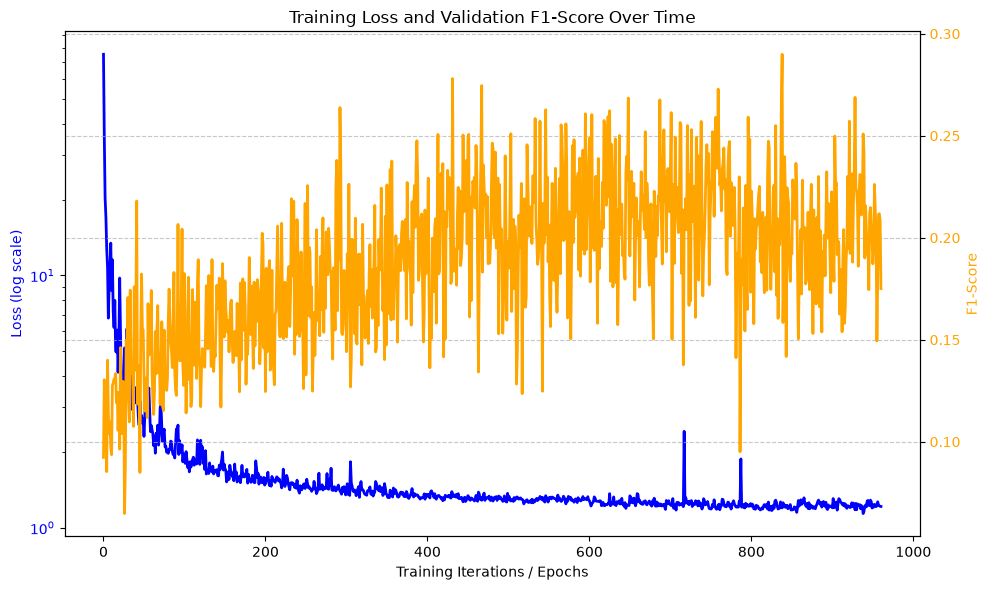

In [ ]:
import os
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best hyperparameters for final training...")
with open(f"{save_to_folder}/best_params.json", "r") as f:
    best_params = json.load(f)

print("\nStarting final training on Train dataset with validation...")

if minibatches:
    data = data.to(device)
    final_train_loader = NeighborLoader(
        data, num_neighbors=num_neighbors, batch_size=batch_size,
        input_nodes=data.train_node_mask, shuffle=True
    )
    final_val_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.val_node_mask, shuffle=False
    )
else:
    final_train_loader = [d_dev]
    final_val_loader = [d_dev]

print(f"Batches per epoch (Final Train): {len(final_train_loader)}")

# Re-initialize the model with best parameters
final_model = GAGNN(
    node_in_dim=x.shape[1],
    edge_feat_dim=edge_attr.shape[1],
    hidden_dim=best_params['hidden_dim'],
    out_dim=best_params['out_dim'],
    heads=best_params['heads'],
    beta=best_params['beta'],
    mlp_hidden_dim=best_params['mlp_hidden_dim'],
    nn_t_hidden_dim=best_params['nn_t_hidden_dim'],
    minibatches=minibatches, num_classes=9,
    gnn_type=gnn_type,
    num_layers=best_params['num_layers']
).to(device)

final_criterion = GAGNNLoss(c1=best_params['c1'], c2=best_params['c2'], c3=best_params['c3'], laundry_weight=class_weights, task='multiclass')
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params['lr'])
scaler = torch.amp.GradScaler('cuda')

os.makedirs(save_to_folder, exist_ok=True)

best_final_val_f1 = -1.0
epochs_no_improve = 0

for epoch in range(epochs_train):
    final_model.train()
    epoch_loss = 0.0
    n_batches = 0
    
    evaluated_train = torch.zeros(data.num_edges, dtype=torch.bool, device=device)
    for batch in final_train_loader:
        if hasattr(batch, 'e_id'):
            e_id = batch.e_id
            new_mask = ~evaluated_train[e_id]
            evaluated_train[e_id] = True
        else:
            new_mask = torch.ones(batch.num_edges, dtype=torch.bool, device=device)
        train_mask = new_mask & batch.edge_train_mask
        if not train_mask.any():
            continue
        final_optimizer.zero_grad()
        
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            p_node, p_trans, p_group, y_group = final_model(
                batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                y_node=batch.y_node, y_trans=batch.y_trans, trans_mask=train_mask
            )
        
        if p_group.numel() > 0:
            loss, _, _, _ = final_criterion(
                p_node, batch.y_node.view(-1, 1),
                p_trans, batch.y_trans,
                p_group, y_group,
                node_mask=batch.node_mask,
                trans_mask=train_mask
            )
            scaler.scale(loss).backward()
            scaler.unscale_(final_optimizer)
            torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=best_params['max_norm'])
            scaler.step(final_optimizer)
            scaler.update()
            epoch_loss += loss.item()
            n_batches += 1
            
    train_loss = epoch_loss / max(n_batches, 1)
    final_model.training_losses.append(train_loss)
    
    # Validation step
    final_model.eval()
    all_preds = []
    all_labels = []
    evaluated_val = torch.zeros(data.num_edges, dtype=torch.bool, device=device)
    with torch.no_grad():
        for batch in final_val_loader:
            if hasattr(batch, 'e_id'):
                e_id = batch.e_id
                new_mask = ~evaluated_val[e_id]
                evaluated_val[e_id] = True
            else:
                new_mask = torch.ones(batch.num_edges, dtype=torch.bool, device=device)
            val_mask = new_mask & batch.edge_val_mask
            if not val_mask.any():
                continue
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                p_node, p_trans, p_group, y_group = final_model(
                    batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                    y_trans=batch.y_trans, trans_mask=batch.edge_val_mask
                )
            if p_group.numel() > 0:
                p_trans_val = p_trans[val_mask]
                y_trans_val = batch.y_trans[val_mask]
                probs = torch.softmax(p_trans_val, dim=1)
                probs_flat = probs
                preds = torch.argmax(probs, dim=1)
                labels = y_trans_val.view(-1).long()
                all_preds.append(preds)
                all_labels.append(labels)
                
    if len(all_preds) > 0:
        all_preds = torch.cat(all_preds).cpu().numpy()
        all_labels = torch.cat(all_labels).cpu().numpy()
        val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    else:
        val_f1 = 0.0
        
    final_model.val_F1.append(val_f1)
    
    if (epoch + 1) % print_every == 0:
        print(f"Train Epoch {epoch+1:03d}/{epochs_train} | Train Loss: {train_loss:.4f} | Val F1: {val_f1:.4f}")
        
    window_size = min(len(final_model.val_F1), moving_average_epochs)
    ma_val_f1 = sum(final_model.val_F1[-window_size:]) / window_size

    if ma_val_f1 > best_final_val_f1:
        best_final_val_f1 = ma_val_f1
        epochs_no_improve = 0
        final_model.save(f"{save_to_folder}/model_trained_final.pt")
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= patience_training:
        print(f"Patience triggered at epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val F1-score: {val_f1:.4f}")
        break
        
    # Save model every 10 epochs
    if (epoch + 1) % save_every == 0:
        final_model.save(f"{save_to_folder}/model_trained_{epoch+1}.pt")

print("\nPlotting training history of the final trained model...")
final_model.plot_training_history()


Loading best model for final evaluation on Test set...
    EVALUATION REPORT (Transactions / Edges)
  Accuracy  : 0.6565
  Precision : 0.2262
  Recall    : 0.2517
  F1-Score  : 0.2260
  ROC-AUC   : 0.8033
--------------------------------------------------
                precision    recall  f1-score   support

         LEGIT       0.76      0.96      0.85      1922
       FAN-OUT       0.00      0.00      0.00       140
        FAN-IN       0.35      0.62      0.45       137
         CYCLE       0.00      0.00      0.00       109
GATHER-SCATTER       0.53      0.44      0.48       401
SCATTER-GATHER       0.17      0.02      0.03       252
     BIPARTITE       0.13      0.12      0.13        74
         STACK       0.09      0.11      0.10       140
        RANDOM       0.00      0.00      0.00        86

      accuracy                           0.66      3261
     macro avg       0.23      0.25      0.23      3261
  weighted avg       0.55      0.66      0.59      3261



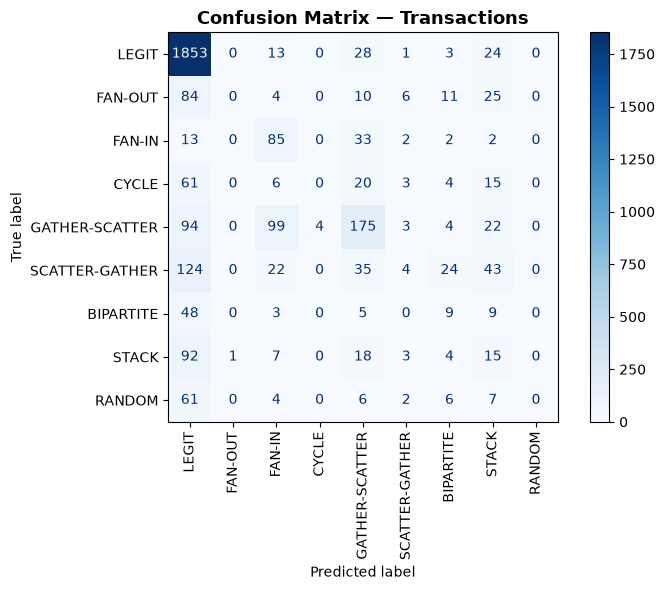

In [ ]:
from utils import Evaluator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best model for final evaluation on Test set...")
eval_model = GAGNN.load_saved(f"{save_to_folder}/model_trained_final.pt").to(device)

with open(f"{save_to_folder}/best_params.json", "r") as f:
    best_params = json.load(f)

eval_criterion = GAGNNLoss(c1=best_params['c1'], c2=best_params['c2'], c3=best_params['c3'], task='multiclass')

if minibatches:
    test_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.test_node_mask, shuffle=False
    )
    Evaluator.evaluation_report(eval_model, test_loader, eval_criterion, device, edge_mask_name='edge_test_mask', task='multiclass')
else:
    Evaluator.evaluation_report(eval_model, [d_dev], eval_criterion, device, edge_mask_name='edge_test_mask', task='multiclass')


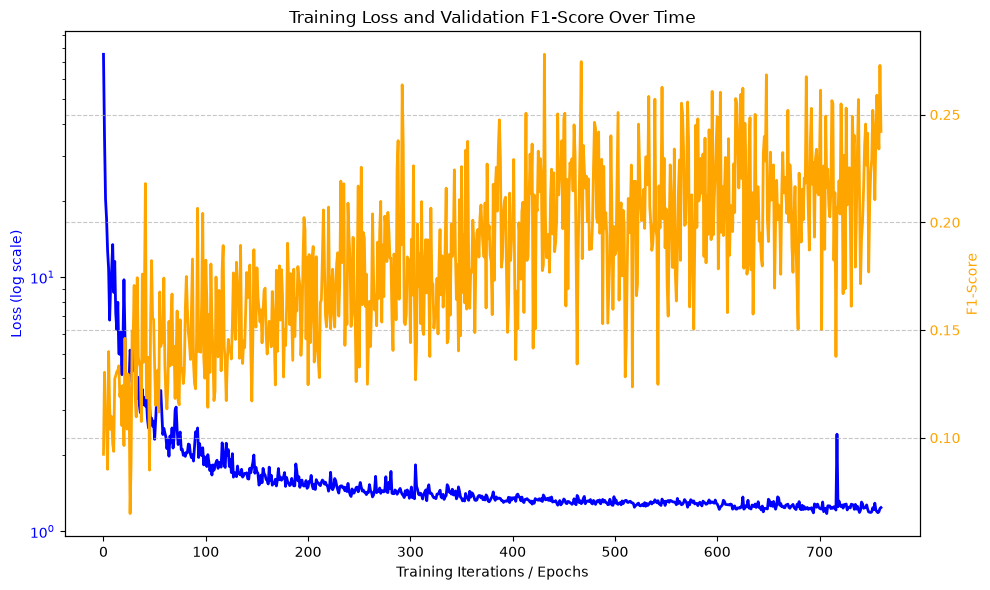

In [ ]:
eval_model.plot_training_history()

## Baseline: Standalone GAT (without GAGNN pipeline)

Ablation study: trains **only the GAT backbone** — no eMRF, no
GroupRepresentationLayer, no multi-task GAGNN loss — as a direct edge-level
Money Laundering classifier.

Edge features are fed **into GNN message passing** (native `edge_dim` support).

The same `data`, `train_node_mask`, `val_node_mask`, and `test_node_mask`
built earlier in this notebook are reused without modification.

In [ ]:
# =============================================================================
# Baseline GAT — Hyperparameter Grid
# =============================================================================
baseline_save_to_folder = 'saved_models_GAT/baseline'

baseline_hidden_dims = [64, 128]
baseline_out_dims = [64, 128, 256]
baseline_num_layers_list = [2, 3]
baseline_mlp_hidden_dims = [64, 128, 256]
baseline_learning_rates = [0.0001]
baseline_laundry_weights = [2.0]
baseline_max_norm_clipping = [5.0]

baseline_heads_list = [3, 5]

baseline_epochs_model_selection = 3000
baseline_epochs_train = 6000

baseline_patience_selection = 100
baseline_moving_average_epochs = 5
moving_average_epochs = 5
baseline_patience_training  = 200


### Baseline — Training

In [ ]:
import os
import json
import numpy as np
from sklearn.metrics import f1_score
from model.standalone_gnn import StandaloneGNN, StandaloneGNNLoss
from torch_geometric.loader import NeighborLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best GAGNN hyperparameters to use for baseline...")
with open(f"{save_to_folder}/best_params.json", "r") as f:
    best_baseline_params = json.load(f)
print(best_baseline_params)

print("\nStarting baseline final training...")

if minibatches:
    data = data.to(device)
    final_train_loader = NeighborLoader(
        data, num_neighbors=num_neighbors, batch_size=batch_size,
        input_nodes=data.train_node_mask, shuffle=True
    )
    final_val_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.val_node_mask, shuffle=False
    )
else:
    d_dev = data.to(device)
    final_train_loader = [d_dev]
    final_val_loader   = [d_dev]

final_model = StandaloneGNN(
    node_in_dim=x.shape[1],
    edge_feat_dim=edge_attr.shape[1],
    hidden_dim=best_baseline_params['hidden_dim'],
    out_dim=best_baseline_params['out_dim'],
    heads=best_baseline_params['heads'],
    num_layers=best_baseline_params['num_layers'],
    gnn_type='gat',
    mlp_hidden_dim=best_baseline_params['mlp_hidden_dim'],
    minibatches=minibatches, num_classes=9,
).to(device)

final_criterion = StandaloneGNNLoss(
    laundry_weight=best_baseline_params['laundry_weight'], task='multiclass'
)
final_optimizer = torch.optim.Adam(
    final_model.parameters(), lr=best_baseline_params['lr']
)
scaler = torch.amp.GradScaler('cuda')

os.makedirs(baseline_save_to_folder, exist_ok=True)

best_final_val_f1 = -1.0
epochs_no_improve = 0

for epoch in range(baseline_epochs_train):
    final_model.train()
    epoch_loss = 0.0
    n_batches  = 0

    evaluated_train = torch.zeros(data.num_edges, dtype=torch.bool, device=device)
    for batch in final_train_loader:
        if hasattr(batch, 'e_id'):
            e_id = batch.e_id
            new_mask = ~evaluated_train[e_id]
            evaluated_train[e_id] = True
        else:
            new_mask = torch.ones(batch.num_edges, dtype=torch.bool, device=device)
        train_mask = new_mask & batch.edge_train_mask
        if not train_mask.any():
            continue
        final_optimizer.zero_grad()

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                p_trans = final_model(batch.x, batch.edge_index, batch.edge_attr)
                loss = final_criterion(p_trans, batch.y_trans, trans_mask=train_mask)

        scaler.scale(loss).backward()
        scaler.unscale_(final_optimizer)
        torch.nn.utils.clip_grad_norm_(
            final_model.parameters(), best_baseline_params['max_norm']
        )
        scaler.step(final_optimizer)
        scaler.update()

        epoch_loss += loss.item()
        n_batches  += 1

    final_model.training_losses.append(epoch_loss / max(n_batches, 1))

    # --- Validation ---
    final_model.eval()
    val_preds, val_labels = [], []
    evaluated_val = torch.zeros(data.num_edges, dtype=torch.bool, device=device)
    with torch.no_grad():
        for batch in final_val_loader:
            if hasattr(batch, 'e_id'):
                e_id = batch.e_id
                new_mask = ~evaluated_val[e_id]
                evaluated_val[e_id] = True
            else:
                new_mask = torch.ones(batch.num_edges, dtype=torch.bool, device=device)
            val_mask = new_mask & batch.edge_val_mask
            if not val_mask.any():
                continue
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    p_trans = final_model(batch.x, batch.edge_index, batch.edge_attr)
            probs   = torch.softmax(p_trans[val_mask].float(), dim=1)
            preds   = torch.argmax(probs, dim=1).int()
            labels  = batch.y_trans[val_mask].view(-1).long()
            val_preds.append(preds)
            val_labels.append(labels)

    val_f1 = (
        f1_score(torch.cat(val_labels).cpu().numpy(), torch.cat(val_preds).cpu().numpy(), average='macro', zero_division=0)
        if val_preds else 0.0
    )
    final_model.val_F1.append(val_f1)

    if epoch % print_every == 0:
        avg_loss = epoch_loss / max(n_batches, 1)
        print(f"Epoch {epoch + 1:4d} | Loss {avg_loss:.4f} | Val F1 {val_f1:.4f}")

    window_size = min(len(final_model.val_F1), moving_average_epochs)
    ma_val_f1 = sum(final_model.val_F1[-window_size:]) / window_size

    if ma_val_f1 > best_final_val_f1:
        best_final_val_f1 = ma_val_f1
        epochs_no_improve = 0
        final_model.save(f"{baseline_save_to_folder}/baseline_model_final.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= baseline_patience_training:
        print(f"Early stopping at epoch {epoch + 1}")
        break

print(f"\nBest baseline val F1 (final training): {best_final_val_f1:.4f}")
print("Model saved to baseline_model_final.pt")



Loading best GAGNN hyperparameters to use for baseline...
{'max_norm': 5.0, 'hidden_dim': 128, 'out_dim': 128, 'heads': 5, 'num_layers': 2, 'beta': 0.44, 'mlp_hidden_dim': 128, 'nn_t_hidden_dim': 128, 'lr': 0.0001, 'c1': 0.75, 'c2': 0.75, 'c3': 0.9, 'laundry_weight': 2.0}

Starting baseline final training...
Epoch    1 | Loss 5.9343 | Val F1 0.0000
Epoch   21 | Loss 0.7381 | Val F1 0.0000
Epoch   41 | Loss 0.5370 | Val F1 0.0000
Epoch   61 | Loss 0.5065 | Val F1 0.0000
Epoch   81 | Loss 0.4442 | Val F1 0.0000
Epoch  101 | Loss 0.4648 | Val F1 0.0000
Epoch  121 | Loss 0.4572 | Val F1 0.0000
Epoch  141 | Loss 0.4342 | Val F1 0.0000
Epoch  161 | Loss 0.3760 | Val F1 0.0000
Epoch  181 | Loss 0.4171 | Val F1 0.0000
Epoch  201 | Loss 0.3503 | Val F1 0.0000
Early stopping at epoch 201

Best baseline val F1 (final training): 0.0000
Model saved to baseline_model_final.pt


### Baseline — Evaluation on Test Set

In [ ]:
from model.standalone_gnn import StandaloneGNN
from utils import Evaluator
from torch_geometric.loader import NeighborLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best baseline model for test evaluation...")
baseline_eval_model = StandaloneGNN.load_saved(
    f"{baseline_save_to_folder}/baseline_model_final.pt"
).to(device)

if minibatches:
    baseline_test_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.test_node_mask, shuffle=False
    )
    Evaluator.baseline_evaluation_report(
        baseline_eval_model, baseline_test_loader, device,
        edge_mask_name='edge_test_mask', task='multiclass'
    )
else:
    Evaluator.baseline_evaluation_report(
        baseline_eval_model, [d_dev], device,
        edge_mask_name='edge_test_mask', task='multiclass'
    )



Loading best baseline model for test evaluation...


ValueError: Found input variables with inconsistent numbers of samples: [3261, 29349]

In [ ]:
baseline_eval_model.plot_training_history()